<a href="https://colab.research.google.com/github/RennyDanilo2023/Simulacion-procesos/blob/main/An%C3%A1lisis_de_incertidumbre_y_sensibilidad_del_tiempo_de_congelaci%C3%B3n_en_filetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CELDA 2=============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr
from google.colab import files
import zipfile

# Folder for outputs
OUT_DIR = "/content/freezing_model_outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TAB_DIR = os.path.join(OUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Output folder created:", OUT_DIR)

#CELDA 3=============================
fish_data = pd.DataFrame({
    "Species": [
        "Tilapia",
        "Rainbow trout",
        "Yellowfin tuna",
        "Arapaima",
        "Atlantic cod"
    ],
    "Scientific_name": [
        "Oreochromis niloticus",
        "Oncorhynchus mykiss",
        "Thunnus albacares",
        "Arapaima gigas",
        "Gadus morhua"
    ],
    "Moisture_pct": [78.08, 72.73, 74.00, 71.41, 81.22],
    "Protein_pct": [20.08, 20.87, 24.40, 20.34, 17.81],
    "Fat_pct": [1.70, 5.40, 0.49, 5.58, 0.67],
    "Ash_pct": [0.93, 1.43, 1.64, 1.05, 1.16],
    "Initial_freezing_point_C": [-1.1, -1.4, -1.3, -1.2, -2.2]
})

# Residual fraction: adjusted to avoid negative values when rounded data exceed 100
fish_data["Residual_pct"] = 100 - (
    fish_data["Moisture_pct"] +
    fish_data["Protein_pct"] +
    fish_data["Fat_pct"] +
    fish_data["Ash_pct"]
)

fish_data["Residual_pct"] = fish_data["Residual_pct"].clip(lower=0)

# Convert percentages to mass fractions
for col in ["Moisture_pct", "Protein_pct", "Fat_pct", "Ash_pct", "Residual_pct"]:
    fish_data[col.replace("_pct", "_frac")] = fish_data[col] / 100

fish_data.to_csv(os.path.join(TAB_DIR, "Table_1_fish_composition.csv"), index=False)

fish_data


Output folder created: /content/freezing_model_outputs


,Species,Scientific_name,Moisture_pct,Protein_pct,Fat_pct,Ash_pct,Initial_freezing_point_C,Residual_pct,Moisture_frac,Protein_frac,Fat_frac,Ash_frac,Residual_frac
0,Tilapia,Oreochromis niloticus,78.08,20.08,1.70,0.93,-1.1,0.00,0.7808,0.2008,0.0170,0.0093,0.0000
1,Rainbow trout,Oncorhynchus mykiss,72.73,20.87,5.40,1.43,-1.4,0.00,0.7273,0.2087,0.0540,0.0143,0.0000
2,Yellowfin tuna,Thunnus albacares,74.00,24.40,0.49,1.64,-1.3,0.00,0.7400,0.2440,0.0049,0.0164,0.0000
3,Arapaima,Arapaima gigas,71.41,20.34,5.58,1.05,-1.2,1.62,0.7141,0.2034,0.0558,0.0105,0.0162
4,Atlantic cod,Gadus morhua,81.22,17.81,0.67,1.16,-2.2,0.00,0.8122,0.1781,0.0067,0.0116,0.0000


In [ ]:
#CELDA 4=============================
# Physical constants
L0 = 333700        # Latent heat of fusion of water, J/kg
T_initial = 5.0    # Initial fillet temperature, °C
T_final_center = -20.0  # Final center temperature, °C
T_eutectic = -5.0  # Lower limit for phase-change interval, °C

# Parámetros numéricos optimizados
# N_NODES controla cuántos puntos se usan desde el centro hasta la superficie.
# 31 es más lento. 21 mantiene una malla aceptable y acelera el cálculo.

N_NODES = 11

# Tiempo máximo de simulación en segundos.
# 12 horas es suficiente para estos escenarios de congelación.
MAX_TIME_S = 12 * 3600

# Factor de estabilidad del método explícito.
# 0.35 es conservador. Se mantiene para evitar inestabilidad numérica.
SAFETY_FO = 0.35

print("Numerical parameters loaded")
print("N_NODES:", N_NODES)
print("MAX_TIME_S:", MAX_TIME_S)
print("SAFETY_FO:", SAFETY_FO)

print("Constants loaded")


#CELDA 5=============================

def cp_component(T, component):
    """
    Specific heat capacity in J/kg K.
    Choi and Okos-type correlations.
    T in °C.
    """
    T = np.asarray(T)

    if component == "water":
        return 4176.2 - 0.090864*T + 0.0054731*T**2
    if component == "ice":
        return 2062.3 + 6.0769*T
    if component == "protein":
        return 2008.2 + 1.2089*T - 0.0013129*T**2
    if component == "fat":
        return 1984.2 + 1.4733*T - 0.0048008*T**2
    if component == "ash":
        return 1092.6 + 1.8896*T - 0.0036817*T**2
    if component == "carbohydrate":
        return 1548.8 + 1.9625*T - 0.0059399*T**2

    raise ValueError("Unknown component")


def k_component(T, component):
    """
    Thermal conductivity in W/m K.
    Choi and Okos-type correlations.
    T in °C.
    """
    T = np.asarray(T)

    if component == "water":
        return 0.57109 + 0.0017625*T - 0.0000067036*T**2
    if component == "ice":
        return 2.2196 - 0.0062489*T + 0.00010154*T**2
    if component == "protein":
        return 0.17881 + 0.0011958*T - 0.0000027178*T**2
    if component == "fat":
        return 0.18071 - 0.00027604*T - 0.00000017749*T**2
    if component == "ash":
        return 0.32962 + 0.0014011*T - 0.0000029069*T**2
    if component == "carbohydrate":
        return 0.20141 + 0.0013874*T - 0.0000043312*T**2

    raise ValueError("Unknown component")


def rho_component(T, component):
    """
    Density in kg/m3.
    Choi and Okos-type correlations.
    T in °C.
    """
    T = np.asarray(T)

    if component == "water":
        return 997.18 + 0.0031439*T - 0.0037574*T**2
    if component == "ice":
        return 916.89 - 0.13071*T
    if component == "protein":
        return 1329.9 - 0.5184*T
    if component == "fat":
        return 925.59 - 0.41757*T
    if component == "ash":
        return 2423.8 - 0.28063*T
    if component == "carbohydrate":
        return 1599.1 - 0.31046*T

    raise ValueError("Unknown component")


print("Thermal property functions ready")


Numerical parameters loaded
N_NODES: 11
MAX_TIME_S: 43200
SAFETY_FO: 0.35
Constants loaded
Thermal property functions ready


In [ ]:
#CELDA 6=============================
def ice_fraction(T, Xw, Xp, Tf, Te=T_eutectic):
    """
    Temperature-dependent ice fraction.
    """
    T = np.asarray(T)

    Xb = 0.4 * Xp
    Xwc = max(Xw - Xb, 0)

    Xice = np.zeros_like(T, dtype=float)

    mask_phase = (T <= Tf) & (T >= Te)
    mask_frozen = T < Te

    Xice[mask_phase] = Xwc * ((Tf - T[mask_phase]) / (Tf - Te))
    Xice[mask_frozen] = Xwc

    return Xice


def effective_properties(T, composition):
    """
    Effective density, thermal conductivity, sensible specific heat,
    apparent specific heat, and thermal diffusivity.
    """
    T = np.asarray(T, dtype=float)

    Xw = composition["Moisture_frac"]
    Xp = composition["Protein_frac"]
    Xf = composition["Fat_frac"]
    Xa = composition["Ash_frac"]
    Xr = composition["Residual_frac"]
    Tf = composition["Initial_freezing_point_C"]

    Xb = 0.4 * Xp
    Xwc = max(Xw - Xb, 0)

    Xice = ice_fraction(T, Xw, Xp, Tf)
    Xunfrozen_water = np.maximum(Xw - Xice, 0)

    # Component mass fractions used at each temperature
    mass = {
        "water": Xunfrozen_water,
        "ice": Xice,
        "protein": np.full_like(T, Xp),
        "fat": np.full_like(T, Xf),
        "ash": np.full_like(T, Xa),
        "carbohydrate": np.full_like(T, Xr)
    }

    # Normalize if small deviations occur
    total_mass = sum(mass.values())
    for key in mass:
        mass[key] = mass[key] / total_mass

    # Density by mixture rule
    inv_rho = np.zeros_like(T, dtype=float)
    for comp, Xi in mass.items():
        inv_rho += Xi / rho_component(T, comp)
    rho_eff = 1 / inv_rho

    # Volume fractions
    volume_terms = {}
    volume_sum = np.zeros_like(T, dtype=float)
    for comp, Xi in mass.items():
        volume_terms[comp] = Xi / rho_component(T, comp)
        volume_sum += volume_terms[comp]

    v = {comp: volume_terms[comp] / volume_sum for comp in mass}

    # Thermal conductivity
    k_eff = np.zeros_like(T, dtype=float)
    for comp in mass:
        k_eff += v[comp] * k_component(T, comp)

    # Sensible Cp
    cp_sensible = np.zeros_like(T, dtype=float)
    for comp, Xi in mass.items():
        cp_sensible += Xi * cp_component(T, comp)

    # Apparent Cp
    cp_app = cp_sensible.copy()
    mask_phase = (T <= Tf) & (T >= T_eutectic)
    cp_app[mask_phase] += L0 * Xwc / (Tf - T_eutectic)

    alpha = k_eff / (rho_eff * cp_app)

    return rho_eff, k_eff, cp_sensible, cp_app, alpha

#CELDA 7=============================CELDA 7. Modelo entálpico 1D
# Versión optimizada para que la celda 11 corra más rápido.
# Mantiene el mismo modelo físico: conducción 1D + simetría al centro + convección en superficie.

def simulate_enthalpy_model(composition, D_mm=20, Ta=-30, h=20, return_curve=False):
    """
    Modelo transitorio unidimensional desde el centro hasta la superficie del filete.

    Parámetros:
    composition: composición proximal de la especie.
    D_mm: espesor total del filete en mm.
    Ta: temperatura del aire en °C.
    h: coeficiente convectivo en W/m2 K.
    return_curve: si es True, devuelve también la curva temperatura-tiempo.

    Salida:
    tiempo de congelación en minutos.
    """

    # Convertir espesor de mm a m
    D = D_mm / 1000

    # Se modela desde el centro hasta la superficie.
    # Por eso se usa la mitad del espesor.
    L = D / 2

    # Malla espacial
    x = np.linspace(0, L, N_NODES)
    dx = x[1] - x[0]

    # Temperatura inicial uniforme
    T = np.full(N_NODES, T_initial, dtype=float)

    # Estimación del paso de tiempo estable
    # Se evalúan propiedades entre la temperatura final y la inicial.
    T_test = np.linspace(T_final_center, T_initial, 80)
    _, _, _, _, alpha_test = effective_properties(T_test, composition)

    # Evitar problemas por valores no finitos
    alpha_test = alpha_test[np.isfinite(alpha_test)]

    if len(alpha_test) == 0:
        return np.nan

    alpha_max = np.max(alpha_test)

    if alpha_max <= 0:
        return np.nan

    # Paso temporal estable para el esquema explícito
    dt = SAFETY_FO * dx**2 / alpha_max

    # Límite superior.
    # Antes estaba en 2 s. Aquí se permite hasta 5 s si la estabilidad lo admite.
    dt = min(dt, 5.0)

    # Límite inferior para evitar pasos excesivamente pequeños
    dt = max(dt, 0.05)

    # Tiempo máximo de seguridad
    max_steps = int(MAX_TIME_S / dt) + 1

    time_s = 0.0

    # Guardar curvas solo si se solicitan.
    # En la celda 11 return_curve=False, así se ahorra tiempo y memoria.
    if return_curve:
        times = [0.0]
        center_temps = [T[0]]
        surface_temps = [T[-1]]

    for step in range(max_steps):

        # Propiedades efectivas en todos los nodos
        rho, k, cp_s, cp_app, alpha = effective_properties(T, composition)

        # Si aparece un valor no válido, se detiene el escenario
        if not np.all(np.isfinite(alpha)):
            return np.nan

        Tnew = T.copy()

        # Centro del filete: condición de simetría
        Fo0 = alpha[0] * dt / dx**2
        Tnew[0] = T[0] + 2 * Fo0 * (T[1] - T[0])

        # Nodos internos vectorizados.
        # Esta parte reemplaza el for interno y acelera bastante.
        Fo = alpha[1:-1] * dt / dx**2
        Tnew[1:-1] = T[1:-1] + Fo * (T[2:] - 2*T[1:-1] + T[:-2])

        # Superficie: condición convectiva
        i = N_NODES - 1
        Foi = alpha[i] * dt / dx**2
        Bi = h * dx / max(k[i], 1e-9)

        Tnew[i] = T[i] + 2 * Foi * ((T[i-1] - T[i]) + Bi * (Ta - T[i]))

        # Actualizar temperatura y tiempo
        T = Tnew
        time_s += dt

        # Guardar curva cada 60 s aproximadamente.
        # Esto solo se usa para figuras, no para la celda 11.
        if return_curve:
            if time_s - times[-1] >= 60:
                times.append(time_s)
                center_temps.append(T[0])
                surface_temps.append(T[-1])

        # Criterio de congelación en el centro
        if T[0] <= T_final_center:
            break

    freezing_time_min = time_s / 60

    if return_curve:
        curve = pd.DataFrame({
            "Time_min": np.array(times) / 60,
            "Center_temperature_C": center_temps,
            "Surface_temperature_C": surface_temps
        })
        return freezing_time_min, curve

    return freezing_time_min

In [ ]:
#CELDA 8=============================
def plank_freezing_time(composition, D_mm=20, Ta=-30, h=20):
    """
    Plank equation for flat slab geometry.
    """
    D = D_mm / 1000

    Xw = composition["Moisture_frac"]
    Xp = composition["Protein_frac"]
    Tf = composition["Initial_freezing_point_C"]

    Xb = 0.4 * Xp
    Xwc = max(Xw - Xb, 0)

    # Properties estimated at frozen condition
    Tprop = np.array([-10.0])
    rho, k, cp_s, cp_app, alpha = effective_properties(Tprop, composition)

    rho_f = float(rho[0])
    k_f = float(k[0])

    P = 1/2
    R = 1/8

    denominator = Tf - Ta
    if denominator <= 0:
        return np.nan

    t_seconds = (rho_f * L0 * Xwc / denominator) * ((P * D / h) + (R * D**2 / k_f))

    return t_seconds / 60

#CELDA 9=============================
test_comp = fish_data.iloc[0].to_dict()

t_ent, curve = simulate_enthalpy_model(
    test_comp,
    D_mm=20,
    Ta=-30,
    h=20,
    return_curve=True
)

t_plank = plank_freezing_time(
    test_comp,
    D_mm=20,
    Ta=-30,
    h=20
)

print("Species:", test_comp["Species"])
print("Enthalpy freezing time (min):", round(t_ent, 2))
print("Plank freezing time (min):", round(t_plank, 2))

curve.head()


Species: Tilapia
Enthalpy freezing time (min): 138.16
Plank freezing time (min): 70.59


,Time_min,Center_temperature_C,Surface_temperature_C
0,0.000000,5.000000,5.000000
1,1.003562,4.958480,1.023917
2,2.007124,4.569103,-0.446699
3,3.010685,3.885486,-1.162091
4,4.014247,3.097469,-1.373622


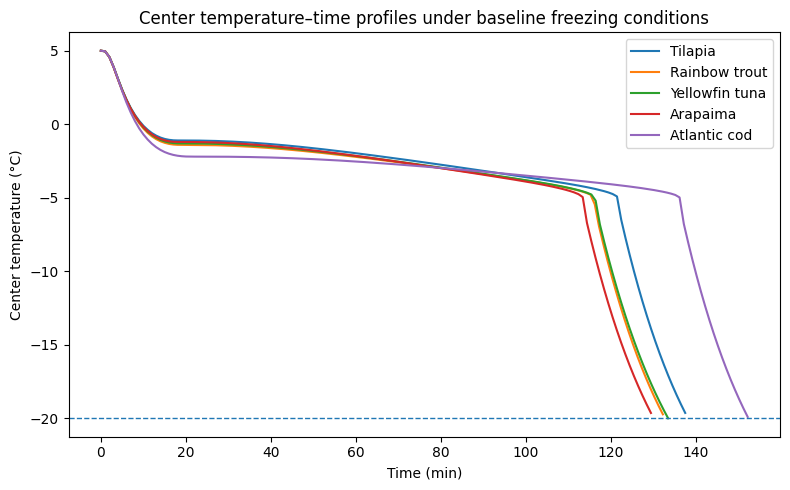

Saved: /content/freezing_model_outputs/figures/Figure_1_center_temperature_time_profiles.png


In [ ]:
#CELDA 10=============================
plt.figure(figsize=(8, 5))

for _, row in fish_data.iterrows():
    comp = row.to_dict()
    t_ent, curve = simulate_enthalpy_model(
        comp,
        D_mm=20,
        Ta=-30,
        h=20,
        return_curve=True
    )

    plt.plot(
        curve["Time_min"],
        curve["Center_temperature_C"],
        label=comp["Species"]
    )

plt.axhline(T_final_center, linestyle="--", linewidth=1)
plt.xlabel("Time (min)")
plt.ylabel("Center temperature (°C)")
plt.title("Center temperature–time profiles under baseline freezing conditions")
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "Figure_1_center_temperature_time_profiles.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [ ]:
# CELDA 11. Simulación determinística de 240 escenarios
# Versión con avance visible en Colab.
# Mantiene las especies, espesores, temperaturas, h y columnas del modelo original.

import os
import time
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from contextlib import contextmanager
import joblib

# Niveles del análisis determinístico
thickness_levels = [10, 20, 30, 40]             # Espesor del filete, mm
air_temperature_levels = [-25, -30, -35, -40]  # Temperatura del aire, °C
h_levels = [10, 20, 30]                         # Coeficiente convectivo, W/m2K

# Archivo de salida
det_path = os.path.join(TAB_DIR, "Table_4_deterministic_freezing_times.csv")


def status_print(message):
    """
    Imprime mensajes de estado en español.
    flush=True ayuda a que Colab muestre el mensaje sin esperar al final.
    """
    print(f"[ESTADO] {message}", flush=True)


# Esta función permite que tqdm muestre avance real con joblib
@contextmanager
def tqdm_joblib(tqdm_object):
    """
    Conecta joblib con tqdm para mostrar una barra de avance real.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# Crear escenarios
scenarios = []

for _, row in fish_data.iterrows():
    comp = row.to_dict()

    for D_mm in thickness_levels:
        for Ta in air_temperature_levels:
            for h in h_levels:
                scenarios.append((comp, D_mm, Ta, h))

total_scenarios = len(scenarios)

status_print(f"Escenarios preparados: {total_scenarios}")
status_print("Iniciando simulación determinística con barra de avance...")

start_time = time.time()


def run_one_scenario(scenario):
    """
    Calcula un escenario determinístico.
    Aquí se calcula el modelo entálpico y la ecuación de Plank.
    """
    comp, D_mm, Ta, h = scenario

    # Modelo principal: conducción transitoria con formulación entálpica
    t_ent = simulate_enthalpy_model(
        comp,
        D_mm=D_mm,
        Ta=Ta,
        h=h,
        return_curve=False
    )

    # Modelo secundario: ecuación de Plank
    t_plank = plank_freezing_time(
        comp,
        D_mm=D_mm,
        Ta=Ta,
        h=h
    )

    # Cálculo de desviación porcentual
    if np.isfinite(t_ent) and t_ent > 0 and np.isfinite(t_plank):
        deviation = abs((t_ent - t_plank) / t_ent) * 100
    else:
        deviation = np.nan

    return {
        "Species": comp["Species"],
        "Scientific_name": comp["Scientific_name"],
        "Thickness_mm": D_mm,
        "Air_temperature_C": Ta,
        "h_W_m2K": h,
        "Enthalpy_time_min": t_ent,
        "Plank_time_min": t_plank,
        "Plank_deviation_pct": deviation
    }


# Ejecución paralela con avance visible
# n_jobs=-1 usa los núcleos disponibles en Colab.
# La barra debe avanzar de 0 a 240.
with tqdm_joblib(tqdm(total=total_scenarios, desc="Calculando escenarios")):
    det_results = Parallel(n_jobs=-1)(
        delayed(run_one_scenario)(scenario)
        for scenario in scenarios
    )

# Crear tabla final
det_df = pd.DataFrame(det_results)

# Ordenar resultados
det_df = det_df.sort_values(
    ["Species", "Thickness_mm", "Air_temperature_C", "h_W_m2K"]
).reset_index(drop=True)

# Guardar resultados
det_df.to_csv(det_path, index=False)

elapsed_time = time.time() - start_time

status_print("Simulación determinística finalizada.")
status_print(f"Número de escenarios calculados: {len(det_df)}")
status_print(f"Tiempo total aproximado: {elapsed_time/60:.2f} min")
status_print(f"Archivo guardado en: {det_path}")

det_df.head()

[ESTADO] Escenarios preparados: 240
[ESTADO] Iniciando simulación determinística con barra de avance...


Calculando escenarios:   0%|          | 0/240 [00:00<?, ?it/s]

[ESTADO] Simulación determinística finalizada.
[ESTADO] Número de escenarios calculados: 240
[ESTADO] Tiempo total aproximado: 25.88 min
[ESTADO] Archivo guardado en: /content/freezing_model_outputs/tables/Table_4_deterministic_freezing_times.csv


,Species,Scientific_name,Thickness_mm,Air_temperature_C,h_W_m2K,Enthalpy_time_min,Plank_time_min,Plank_deviation_pct
0,Arapaima,Arapaima gigas,10,-40,10,77.276358,46.142187,40.289388
1,Arapaima,Arapaima gigas,10,-40,20,42.791965,23.411680,45.289543
2,Arapaima,Arapaima gigas,10,-40,30,30.817023,15.834844,48.616568
3,Arapaima,Arapaima gigas,10,-35,10,88.815945,52.967954,40.362112
4,Arapaima,Arapaima gigas,10,-35,20,48.818851,26.874946,44.949655


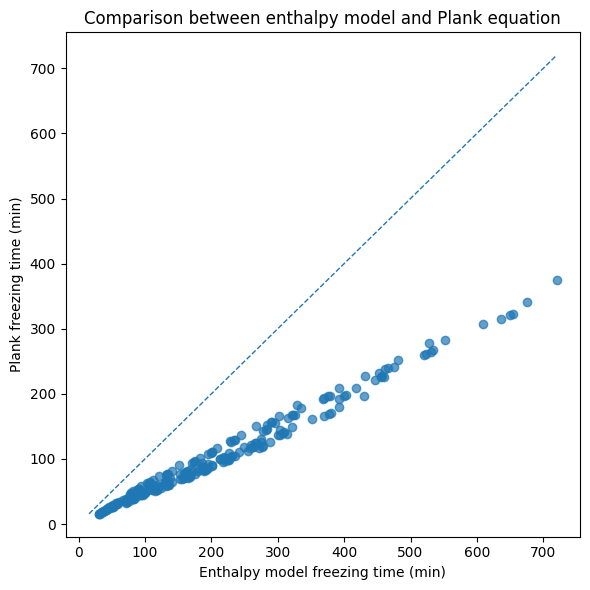

Saved: /content/freezing_model_outputs/figures/Figure_2_enthalpy_vs_plank.png


In [ ]:
#CELDA 12. Resumen determinístico
summary_det = det_df.groupby("Species").agg(
    Mean_enthalpy_time_min=("Enthalpy_time_min", "mean"),
    Min_enthalpy_time_min=("Enthalpy_time_min", "min"),
    Max_enthalpy_time_min=("Enthalpy_time_min", "max"),
    Mean_Plank_deviation_pct=("Plank_deviation_pct", "mean"),
    Max_Plank_deviation_pct=("Plank_deviation_pct", "max")
).reset_index()

summary_det.to_csv(os.path.join(TAB_DIR, "Summary_deterministic_results.csv"), index=False)

summary_det

#CELDA 13. Figura 2: comparación modelo entálpico vs Plank
plt.figure(figsize=(6, 6))

plt.scatter(
    det_df["Enthalpy_time_min"],
    det_df["Plank_time_min"],
    alpha=0.7
)

min_v = min(det_df["Enthalpy_time_min"].min(), det_df["Plank_time_min"].min())
max_v = max(det_df["Enthalpy_time_min"].max(), det_df["Plank_time_min"].max())

plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", linewidth=1)

plt.xlabel("Enthalpy model freezing time (min)")
plt.ylabel("Plank freezing time (min)")
plt.title("Comparison between enthalpy model and Plank equation")
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "Figure_2_enthalpy_vs_plank.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


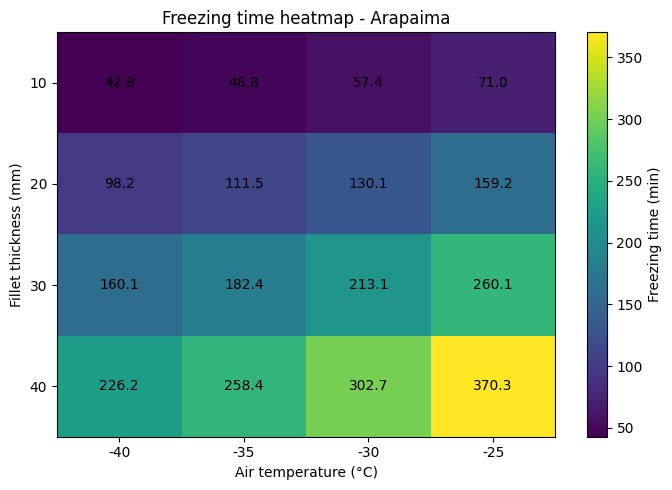

Saved: /content/freezing_model_outputs/figures/Figure_3_heatmap_Arapaima.png


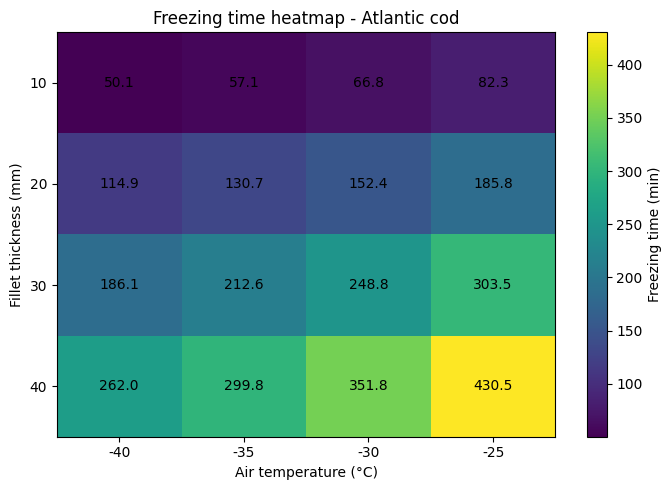

Saved: /content/freezing_model_outputs/figures/Figure_3_heatmap_Atlantic_cod.png


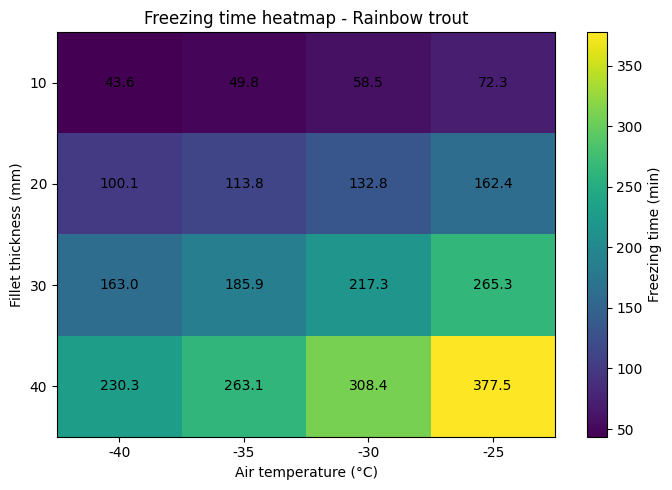

Saved: /content/freezing_model_outputs/figures/Figure_3_heatmap_Rainbow_trout.png


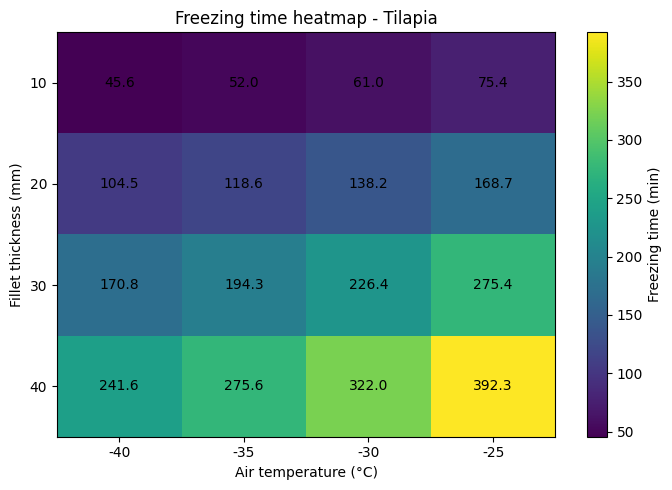

Saved: /content/freezing_model_outputs/figures/Figure_3_heatmap_Tilapia.png


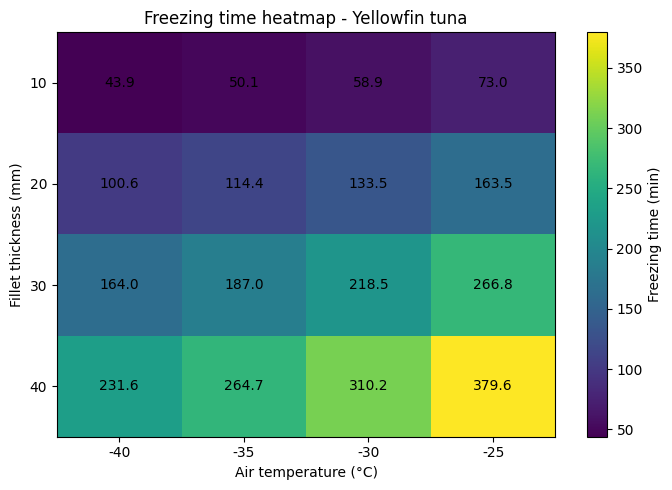

Saved: /content/freezing_model_outputs/figures/Figure_3_heatmap_Yellowfin_tuna.png


In [ ]:
#CELDA 14. Figura 3: mapa de calor por especie
for species in det_df["Species"].unique():
    temp_df = det_df[
        (det_df["Species"] == species) &
        (det_df["h_W_m2K"] == 20)
    ]

    pivot = temp_df.pivot_table(
        index="Thickness_mm",
        columns="Air_temperature_C",
        values="Enthalpy_time_min",
        aggfunc="mean"
    )

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Freezing time (min)")

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.xlabel("Air temperature (°C)")
    plt.ylabel("Fillet thickness (mm)")
    plt.title(f"Freezing time heatmap - {species}")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.values[i, j]:.1f}",
                     ha="center", va="center")

    plt.tight_layout()

    safe_species = species.replace(" ", "_")
    fig_path = os.path.join(FIG_DIR, f"Figure_3_heatmap_{safe_species}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)


In [ ]:
# CELDA 15. Monte Carlo optimizado con barra de avance
# Primero usar 50 o 100 iteraciones para probar.
# Después, si todo corre bien, subir a 200.
# Para un artículo más fuerte se puede usar 1000, pero tardará mucho más.

import os
import time
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from contextlib import contextmanager
import joblib

MC_ITER = 400   # Recomendado ahora. Luego puedes subir a 200. LISTO PARA EJECUUTAR POR 2 VEZ
rng_seed = 123

mc_path = os.path.join(TAB_DIR, "Monte_Carlo_raw_results.csv")


def status_print(message):
    """
    Imprime mensajes de estado en español.
    """
    print(f"[ESTADO] {message}", flush=True)


@contextmanager
def tqdm_joblib(tqdm_object):
    """
    Conecta joblib con tqdm para mostrar avance real.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


def truncated_normal_scalar(rng, mean, sd, low, high):
    """
    Genera un solo valor aleatorio con distribución normal truncada.
    Esta versión evita la advertencia de Colab.
    """
    value = rng.normal(mean, sd)
    value = np.clip(value, low, high)
    return float(value)


# Crear lista de trabajos Monte Carlo
# Cada trabajo representa una especie y una iteración.
mc_jobs = []

for _, row in fish_data.iterrows():
    base = row.to_dict()

    for i in range(MC_ITER):
        mc_jobs.append((base, i + 1))

total_jobs = len(mc_jobs)

status_print(f"Iteraciones Monte Carlo preparadas: {total_jobs}")
status_print("Iniciando Monte Carlo optimizado...")

start_time = time.time()


def run_one_mc(job):
    """
    Ejecuta una simulación Monte Carlo.
    Cada iteración usa una semilla diferente para evitar resultados repetidos.
    """
    base, iteration = job

    # Semilla propia para cada especie e iteración
    local_seed = rng_seed + iteration + abs(hash(base["Species"])) % 10000
    rng = np.random.default_rng(local_seed)

    # Variables de proceso con incertidumbre
    D_sample = truncated_normal_scalar(rng, 20, 2, 10, 40)
    Ta_sample = truncated_normal_scalar(rng, -30, 2, -40, -25)
    h_sample = truncated_normal_scalar(rng, 20, 4, 10, 30)

    # Copia de composición base
    comp_sample = base.copy()

    # Variación aleatoria de composición
    comp_sample["Moisture_frac"] = max(
        float(rng.normal(base["Moisture_frac"], base["Moisture_frac"] * 0.02)),
        0
    )

    comp_sample["Protein_frac"] = max(
        float(rng.normal(base["Protein_frac"], base["Protein_frac"] * 0.02)),
        0
    )

    comp_sample["Fat_frac"] = max(
        float(rng.normal(base["Fat_frac"], max(base["Fat_frac"] * 0.05, 0.0001))),
        0
    )

    comp_sample["Ash_frac"] = max(
        float(rng.normal(base["Ash_frac"], base["Ash_frac"] * 0.05)),
        0
    )

    # Ajuste de fracción residual para mantener suma cercana a 1
    comp_sample["Residual_frac"] = max(
        1 - (
            comp_sample["Moisture_frac"] +
            comp_sample["Protein_frac"] +
            comp_sample["Fat_frac"] +
            comp_sample["Ash_frac"]
        ),
        0
    )

    # Variación del punto inicial de congelación
    comp_sample["Initial_freezing_point_C"] = float(
        rng.normal(base["Initial_freezing_point_C"], 0.15)
    )

    # Modelo entálpico
    t_mc = simulate_enthalpy_model(
        comp_sample,
        D_mm=D_sample,
        Ta=Ta_sample,
        h=h_sample,
        return_curve=False
    )

    return {
        "Species": base["Species"],
        "Iteration": iteration,
        "Thickness_mm": D_sample,
        "Air_temperature_C": Ta_sample,
        "h_W_m2K": h_sample,
        "Moisture_frac": comp_sample["Moisture_frac"],
        "Protein_frac": comp_sample["Protein_frac"],
        "Fat_frac": comp_sample["Fat_frac"],
        "Ash_frac": comp_sample["Ash_frac"],
        "Initial_freezing_point_C": comp_sample["Initial_freezing_point_C"],
        "Freezing_time_min": t_mc
    }


# Ejecución paralela con barra de avance
with tqdm_joblib(tqdm(total=total_jobs, desc="Monte Carlo")):
    mc_results = Parallel(n_jobs=-1)(
        delayed(run_one_mc)(job)
        for job in mc_jobs
    )

# Convertir a DataFrame
mc_df = pd.DataFrame(mc_results)

# Ordenar resultados
mc_df = mc_df.sort_values(
    ["Species", "Iteration"]
).reset_index(drop=True)

# Guardar archivo CSV
mc_df.to_csv(mc_path, index=False)

elapsed_time = time.time() - start_time

status_print("Monte Carlo finalizado.")
status_print(f"Total de simulaciones Monte Carlo: {len(mc_df)}")
status_print(f"Tiempo total aproximado: {elapsed_time/60:.2f} min")
status_print(f"Archivo guardado en: {mc_path}")

mc_df.head()

[ESTADO] Iteraciones Monte Carlo preparadas: 500
[ESTADO] Iniciando Monte Carlo optimizado...


Monte Carlo:   0%|          | 0/500 [00:00<?, ?it/s]

[ESTADO] Monte Carlo finalizado.
[ESTADO] Total de simulaciones Monte Carlo: 500
[ESTADO] Tiempo total aproximado: 47.60 min
[ESTADO] Archivo guardado en: /content/freezing_model_outputs/tables/Monte_Carlo_raw_results.csv


,Species,Iteration,Thickness_mm,Air_temperature_C,h_W_m2K,Moisture_frac,Protein_frac,Fat_frac,Ash_frac,Initial_freezing_point_C,Freezing_time_min
0,Arapaima,1,19.698706,-30.307225,27.155464,0.712153,0.197996,0.056714,0.010662,-1.263249,99.823810
1,Arapaima,2,17.893137,-27.055809,18.058268,0.699210,0.206092,0.054678,0.011733,-1.223800,136.669948
2,Arapaima,3,18.867467,-29.871626,23.699648,0.728333,0.209136,0.056170,0.010032,-1.292014,107.974151
3,Arapaima,4,24.306010,-31.278754,19.529947,0.735837,0.206690,0.057208,0.009877,-1.262308,164.263102
4,Arapaima,5,21.912391,-32.965853,24.468366,0.727434,0.202104,0.058410,0.009989,-1.183921,113.848874


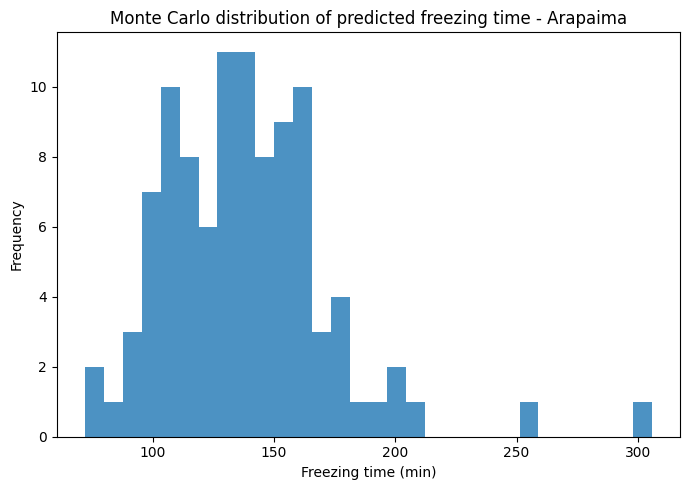

Saved: /content/freezing_model_outputs/figures/Figure_4_monte_carlo_distribution_Arapaima.png


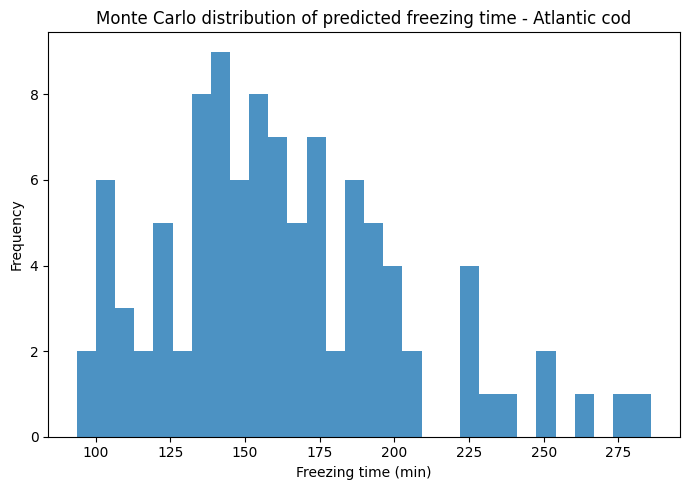

Saved: /content/freezing_model_outputs/figures/Figure_4_monte_carlo_distribution_Atlantic_cod.png


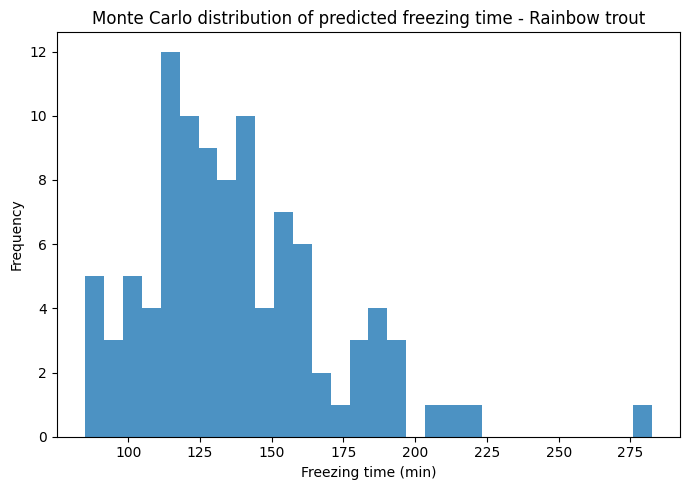

Saved: /content/freezing_model_outputs/figures/Figure_4_monte_carlo_distribution_Rainbow_trout.png


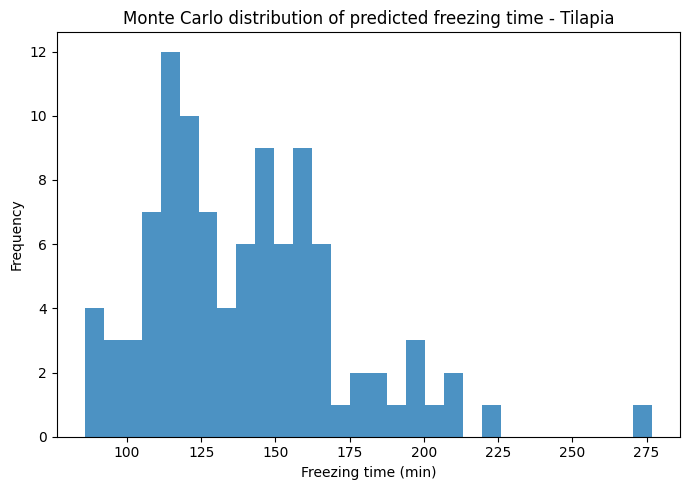

Saved: /content/freezing_model_outputs/figures/Figure_4_monte_carlo_distribution_Tilapia.png


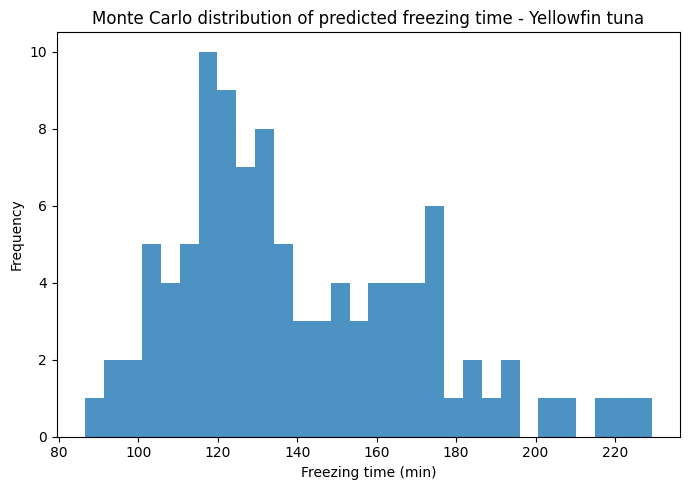

Saved: /content/freezing_model_outputs/figures/Figure_4_monte_carlo_distribution_Yellowfin_tuna.png


In [ ]:
for species in mc_df["Species"].unique():
    temp = mc_df[mc_df["Species"] == species]

    plt.figure(figsize=(7, 5))
    plt.hist(temp["Freezing_time_min"], bins=30, alpha=0.8)

    plt.xlabel("Freezing time (min)")
    plt.ylabel("Frequency")
    plt.title(f"Monte Carlo distribution of predicted freezing time - {species}")

    plt.tight_layout()

    safe_species = species.replace(" ", "_")
    fig_path = os.path.join(FIG_DIR, f"Figure_4_monte_carlo_distribution_{safe_species}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)


In [ ]:
#CELDA 18. Sensibilidad global con Spearman y beta estandarizado
input_vars = [
    "Thickness_mm",
    "Air_temperature_C",
    "h_W_m2K",
    "Moisture_frac",
    "Protein_frac",
    "Fat_frac",
    "Ash_frac",
    "Initial_freezing_point_C"
]

sensitivity_results = []

for species in mc_df["Species"].unique():
    temp = mc_df[mc_df["Species"] == species].copy()

    y = temp["Freezing_time_min"].values
    X = temp[input_vars].values

    # Standardization
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=1)
    X_std[X_std == 0] = 1

    y_mean = y.mean()
    y_std = y.std(ddof=1)

    Xz = (X - X_mean) / X_std
    yz = (y - y_mean) / y_std

    # Linear regression with intercept
    X_design = np.column_stack([np.ones(len(Xz)), Xz])
    beta = np.linalg.lstsq(X_design, yz, rcond=None)[0][1:]

    beta_abs_sum = np.sum(np.abs(beta))
    contribution = np.abs(beta) / beta_abs_sum * 100

    for j, var in enumerate(input_vars):
        rho_s, p_value = spearmanr(temp[var], temp["Freezing_time_min"])

        sensitivity_results.append({
            "Species": species,
            "Input_variable": var,
            "Spearman_rho": rho_s,
            "Spearman_p_value": p_value,
            "Standardized_beta": beta[j],
            "Relative_contribution_pct": contribution[j]
        })

sens_df = pd.DataFrame(sensitivity_results)

sens_df["Rank"] = sens_df.groupby("Species")["Relative_contribution_pct"].rank(
    ascending=False,
    method="dense"
)

sens_df = sens_df.sort_values(["Species", "Rank"])

sens_df.to_csv(os.path.join(TAB_DIR, "Table_6_global_sensitivity_ranking.csv"), index=False)

sens_df.head(20)


,Species,Input_variable,Spearman_rho,Spearman_p_value,Standardized_beta,Relative_contribution_pct,Rank
2,Arapaima,h_W_m2K,-0.797506,3.119393e-23,-0.771193,47.864463,1.0
0,Arapaima,Thickness_mm,0.420054,1.356714e-05,0.462704,28.717965,2.0
1,Arapaima,Air_temperature_C,0.325200,9.622613e-04,0.281235,17.454969,3.0
3,Arapaima,Moisture_frac,-0.016970,8.669172e-01,0.038754,2.405287,4.0
6,Arapaima,Ash_frac,-0.005977,9.529401e-01,0.019261,1.195445,5.0
7,Arapaima,Initial_freezing_point_C,0.067303,5.058454e-01,-0.015608,0.968729,6.0
4,Arapaima,Protein_frac,-0.049253,6.265188e-01,-0.014062,0.872766,7.0
5,Arapaima,Fat_frac,-0.166025,9.876899e-02,0.008384,0.520377,8.0
10,Atlantic cod,h_W_m2K,-0.831335,9.623942e-27,-0.795379,50.194722,1.0
8,Atlantic cod,Thickness_mm,0.423786,1.115487e-05,0.388269,24.502859,2.0


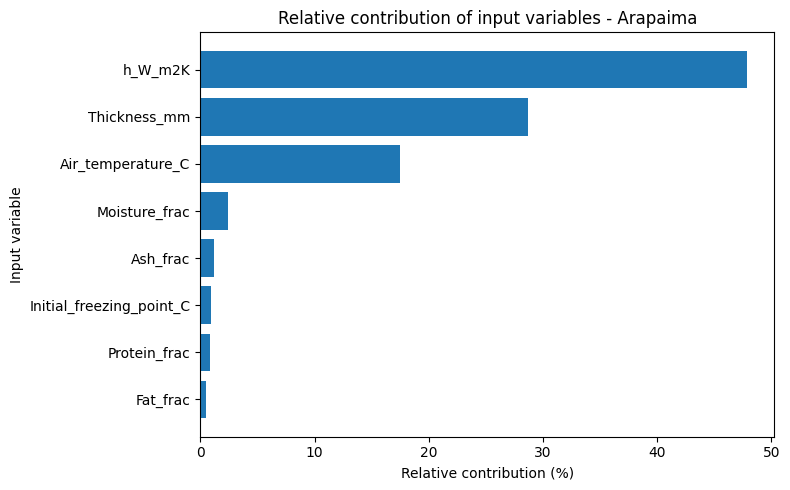

Saved: /content/freezing_model_outputs/figures/Figure_5_relative_contribution_Arapaima.png


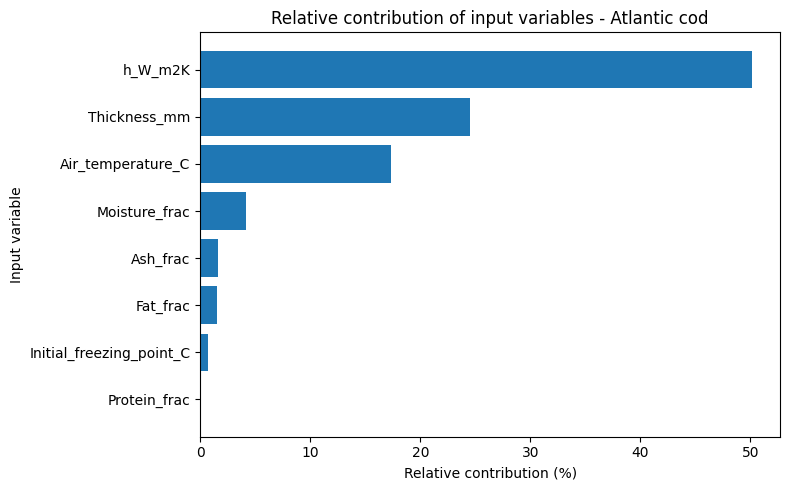

Saved: /content/freezing_model_outputs/figures/Figure_5_relative_contribution_Atlantic_cod.png


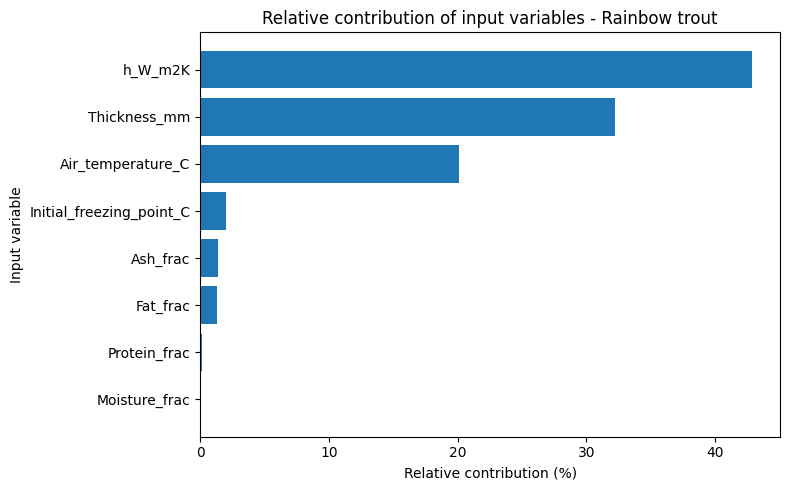

Saved: /content/freezing_model_outputs/figures/Figure_5_relative_contribution_Rainbow_trout.png


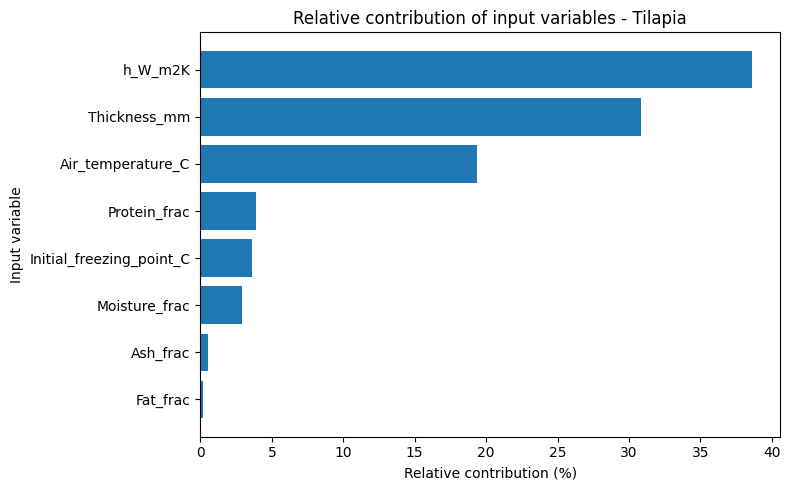

Saved: /content/freezing_model_outputs/figures/Figure_5_relative_contribution_Tilapia.png


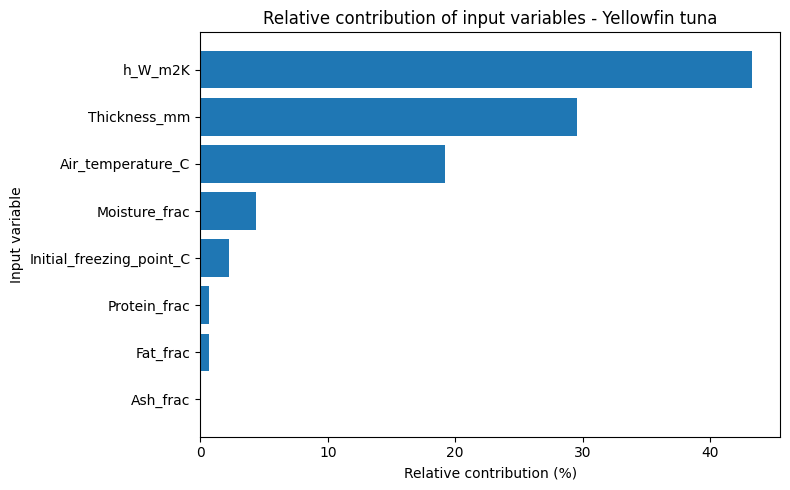

Saved: /content/freezing_model_outputs/figures/Figure_5_relative_contribution_Yellowfin_tuna.png


In [ ]:
#CELDA 19. Figura 5: contribución relativa
for species in sens_df["Species"].unique():
    temp = sens_df[sens_df["Species"] == species].sort_values(
        "Relative_contribution_pct",
        ascending=True
    )

    plt.figure(figsize=(8, 5))
    plt.barh(
        temp["Input_variable"],
        temp["Relative_contribution_pct"]
    )

    plt.xlabel("Relative contribution (%)")
    plt.ylabel("Input variable")
    plt.title(f"Relative contribution of input variables - {species}")

    plt.tight_layout()

    safe_species = species.replace(" ", "_")
    fig_path = os.path.join(FIG_DIR, f"Figure_5_relative_contribution_{safe_species}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)


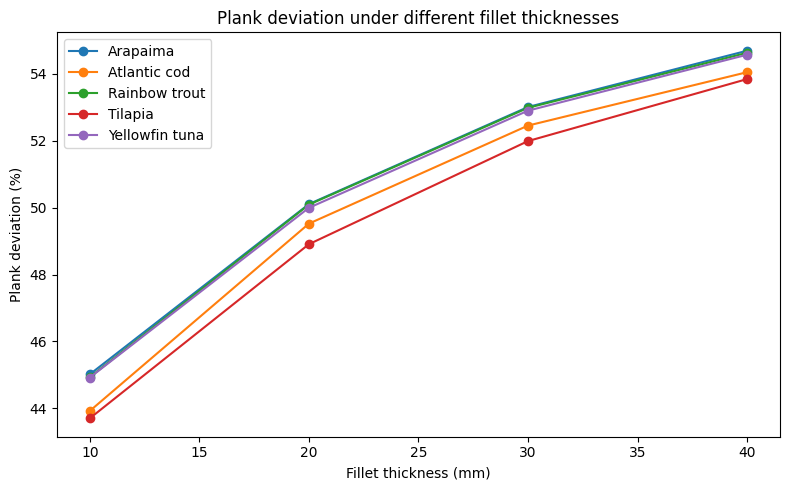

Saved: /content/freezing_model_outputs/figures/Figure_6_plank_deviation_by_thickness.png


In [ ]:
#CELDA 20. Desviación de Plank según espesor
plt.figure(figsize=(8, 5))

for species in det_df["Species"].unique():
    temp = det_df[
        (det_df["Species"] == species) &
        (det_df["Air_temperature_C"] == -30) &
        (det_df["h_W_m2K"] == 20)
    ].sort_values("Thickness_mm")

    plt.plot(
        temp["Thickness_mm"],
        temp["Plank_deviation_pct"],
        marker="o",
        label=species
    )

plt.xlabel("Fillet thickness (mm)")
plt.ylabel("Plank deviation (%)")
plt.title("Plank deviation under different fillet thicknesses")
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "Figure_6_plank_deviation_by_thickness.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


In [ ]:
#CELDA 21. Exportar todo en ZIP
zip_path = "/content/freezing_model_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(OUT_DIR):
        for file in files_in_dir:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUT_DIR)
            zipf.write(full_path, arcname)

print("ZIP created:", zip_path)

files.download(zip_path)


ZIP created: /content/freezing_model_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>